In [1]:
# load libraries and setup tokamaker
import os
import sys
import numpy as np
import time
import matplotlib.pyplot as plt
from omfit_classes.utils_fusion import sauter_bootstrap, Hmode_profiles

plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

tokamaker_python_path = os.getenv('OFT_ROOTPATH')

if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, create_power_flux_fun
# from OpenFUSIONToolkit.TokaMaker.bootstrap import solve_with_bootstrap

myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('ITER_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.settings.maxits=100


#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           51e08bd
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/9p/90ydvncx0zb8sqr976fmrfxr0000gn/T/oft_31724/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.859E+02
    # of points  =    4757
    # of edges   =   14156
    # of cells   =    9400
    # of boundary points =     112
    # of boundary edges  =     112
    # of boundary cells  =     112
  Resolution statistics:
    hmin =  9.924E-03
    hrms =  2.826E-01
    hmax =  8.466E-01
  Surface grounded at vertex     870



In [2]:
R0 = 6.2 # m
B0 = 5.3 # T
mygs.setup(order = 2, F0 = R0*B0)


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    6.3800000000000000E-004


In [3]:
ffp_prof = create_power_flux_fun(40,1.5,2.0)
pp_prof = create_power_flux_fun(40,4.0,1.0)
mygs.set_profiles(ffp_prof=ffp_prof,pp_prof=pp_prof)

In [4]:
kappa = 1.878
delta = 0.4
a = 1.89
Z = 0.5

In [5]:
# boundary = create_isoflux(20, R0, Z, a, kappa, delta)
boundary = np.array([
    [ 8.20,  0.41],
    [ 8.06,  1.46],
    [ 7.51,  2.62],
    [ 6.14,  3.78],
    [ 4.51,  3.02],
    [ 4.26,  1.33],
    [ 4.28,  0.08],
    [ 4.49, -1.34],
    [ 7.28, -1.89],
    [ 8.00, -0.68]
])
iso_weight = 500
isoflux_weights = iso_weight * np.ones(len(boundary))
mygs.set_isoflux(boundary, isoflux_weights)
mygs.set_saddles(np.array([[5.125,-3.4]]))

mygs.set_coil_vsc({'VS': 1.0})
coil_bounds = {key: [-50.E6, 50.E6] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)
# Set regularization weights
regularization_terms = []
for name, coil in mygs.coil_sets.items():
    # Set zero target current and different small weights to help conditioning of fit
    if name.startswith('CS'):
        if name.startswith('CS1'):
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=2.E-2))
        else:
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E-2))
    elif name.startswith('PF'):
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E-2))
    elif name.startswith('VS'):
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E-2))
# Disable VSC virtual coil
regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E2))
# Pass regularization terms to TokaMaker
mygs.set_coil_reg(reg_terms=regularization_terms)
mygs.init_psi(R0, Z, a, kappa, delta)


Starting non-linear GS solver
     1  6.4739E+00  7.2465E-04  4.5494E-01  6.3101E+00  5.6081E-01 -4.4152E-04
     2  6.3399E+00  1.6819E-03  9.2023E-02  6.3103E+00  5.6082E-01 -4.3880E-04
     3  6.2411E+00  2.2953E-03  1.9261E-02  6.3117E+00  5.6072E-01 -4.3837E-04
     4  6.1976E+00  2.4847E-03  4.3512E-03  6.3128E+00  5.6061E-01 -4.3999E-04
     5  6.1787E+00  2.5312E-03  1.2194E-03  6.3135E+00  5.6054E-01 -4.4196E-04
     6  6.1693E+00  2.5430E-03  5.2436E-04  6.3138E+00  5.6049E-01 -4.4356E-04
     7  6.1641E+00  2.5466E-03  3.0173E-04  6.3140E+00  5.6048E-01 -4.4470E-04
     8  6.1612E+00  2.5480E-03  1.8614E-04  6.3141E+00  5.6047E-01 -4.4546E-04
     9  6.1594E+00  2.5487E-03  1.1547E-04  6.3141E+00  5.6048E-01 -4.4594E-04
    10  6.1584E+00  2.5491E-03  7.1290E-05  6.3141E+00  5.6048E-01 -4.4625E-04
    11  6.1578E+00  2.5493E-03  4.3774E-05  6.3141E+00  5.6049E-01 -4.4643E-04
    12  6.1574E+00  2.5494E-03  2.6783E-05  6.3141E+00  5.6050E-01 -4.4655E-04
    13  6.1572E+00  2.

    14  2.4599E+00  3.1251E-02  7.9324E-05  6.4298E+00  5.4564E-01 -5.8302E-04
    15  2.4589E+00  3.1255E-02  4.8551E-05  6.4298E+00  5.4562E-01 -5.8293E-04
    16  2.4583E+00  3.1258E-02  2.9658E-05  6.4298E+00  5.4561E-01 -5.8288E-04
    17  2.4579E+00  3.1260E-02  1.8090E-05  6.4298E+00  5.4561E-01 -5.8285E-04
    18  2.4577E+00  3.1261E-02  1.1021E-05  6.4299E+00  5.4561E-01 -5.8284E-04
    19  2.4576E+00  3.1261E-02  6.7082E-06  6.4299E+00  5.4560E-01 -5.8282E-04
    20  2.4575E+00  3.1262E-02  4.0806E-06  6.4299E+00  5.4560E-01 -5.8282E-04
    21  2.4574E+00  3.1262E-02  2.4810E-06  6.4299E+00  5.4560E-01 -5.8281E-04
    22  2.4574E+00  3.1262E-02  1.5079E-06  6.4299E+00  5.4560E-01 -5.8281E-04
    23  2.4574E+00  3.1262E-02  9.1618E-07  6.4299E+00  5.4560E-01 -5.8281E-04
 Timing:  0.17165699996985495     
   Source:     7.1914999629370868E-002
   Solve:      5.1515999948605895E-002
   Boundary:   6.2770000658929348E-003
   Other:      4.1949000325985253E-002
Saving gEQDSK: eqds

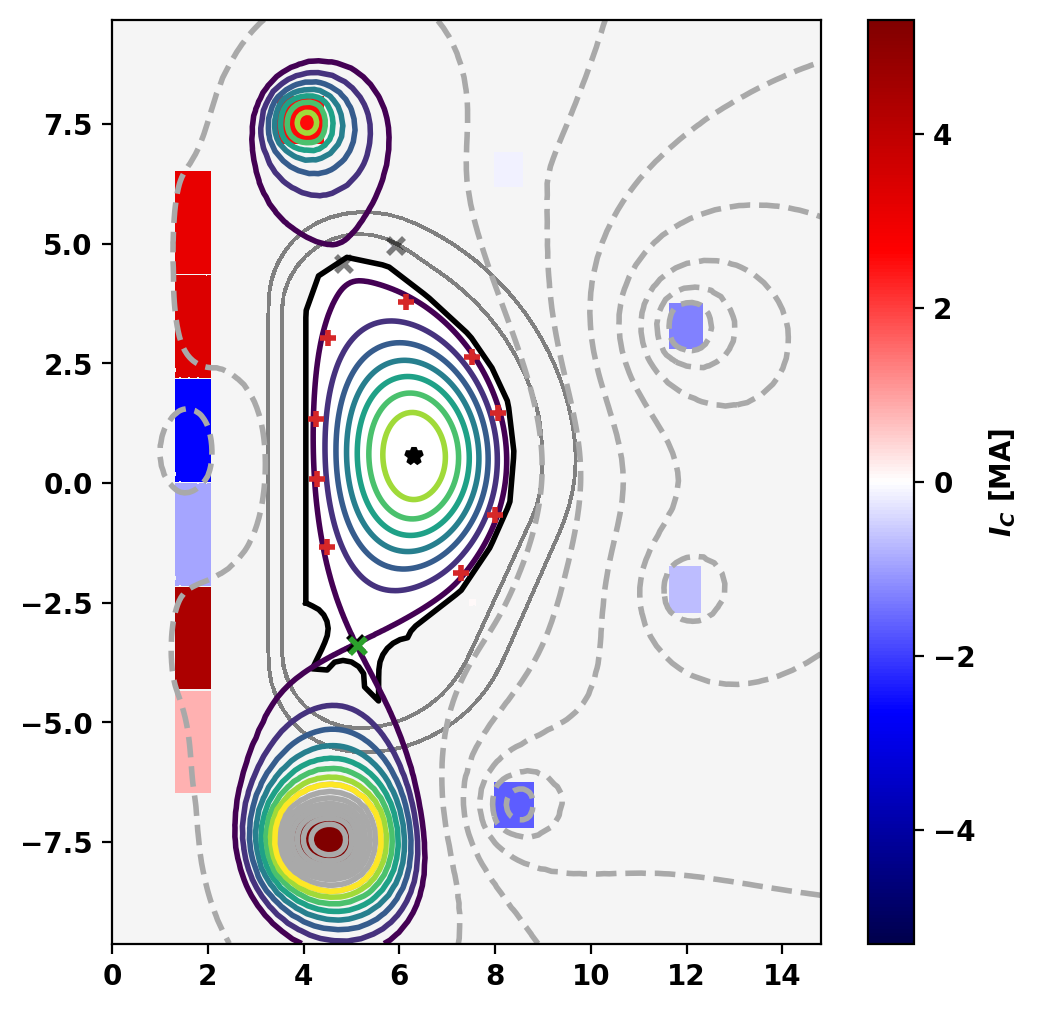

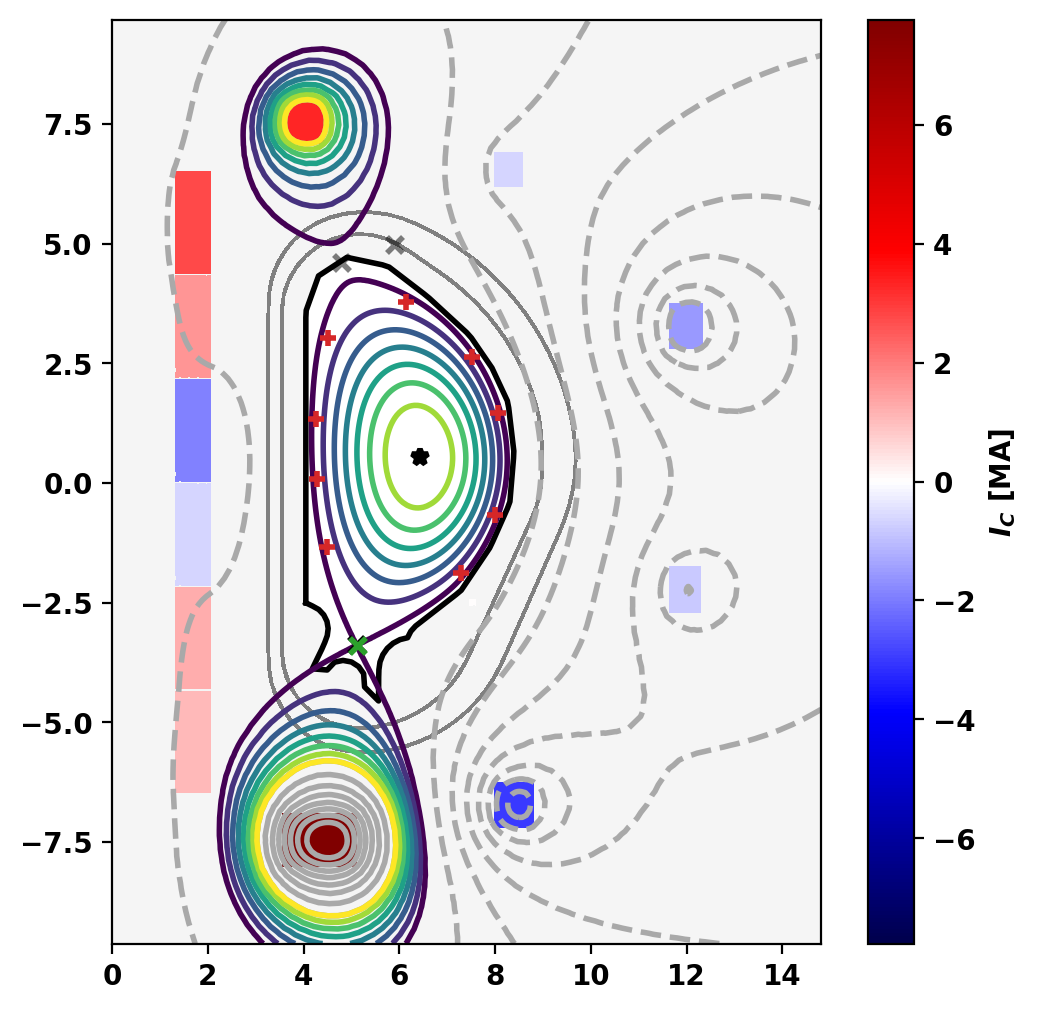

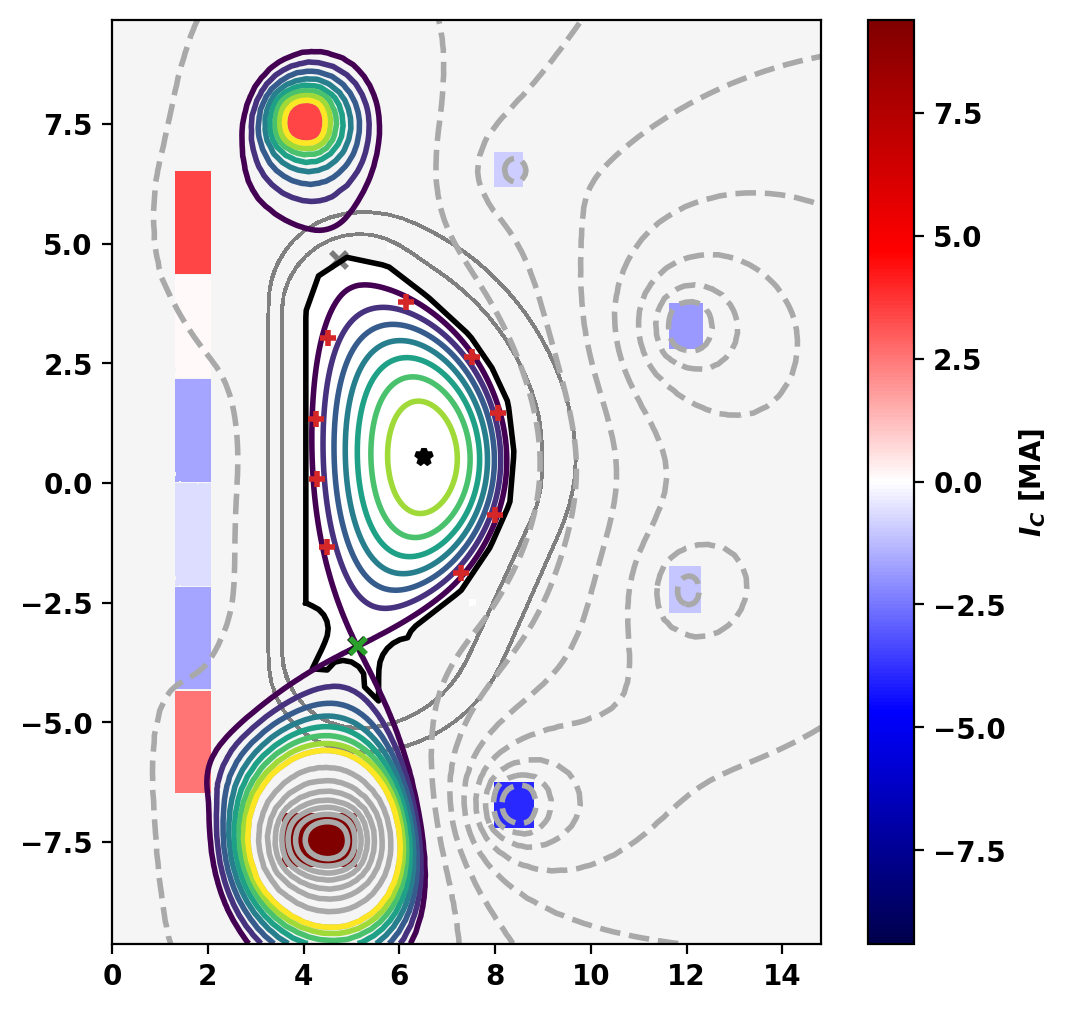

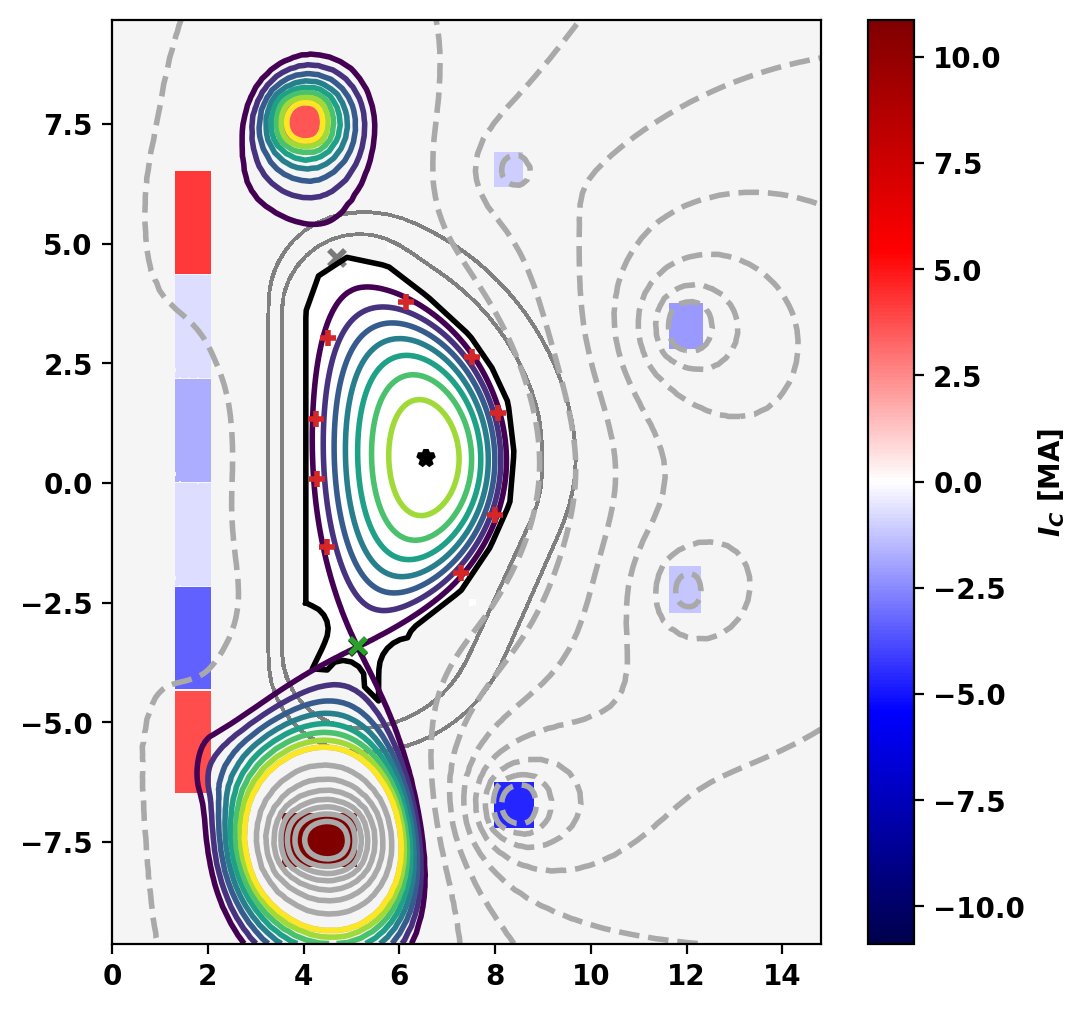

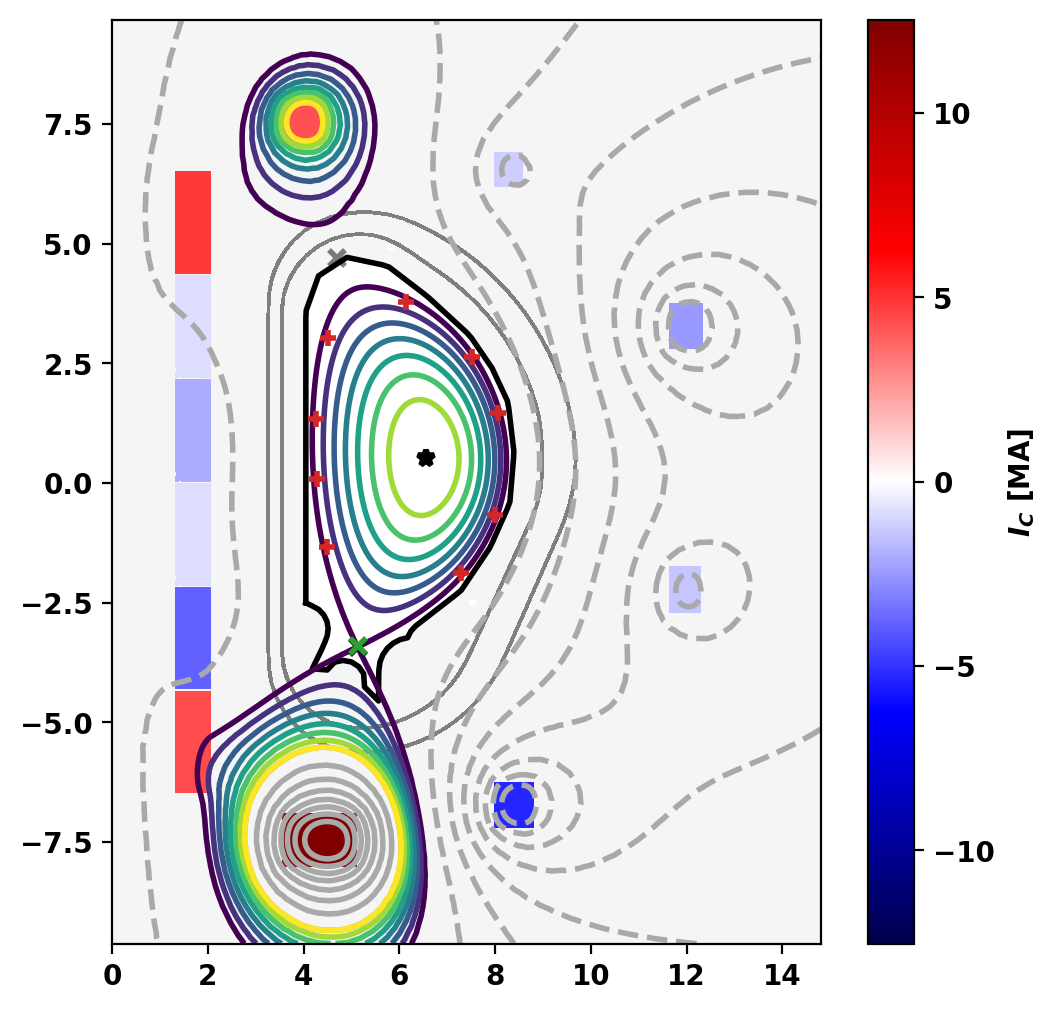

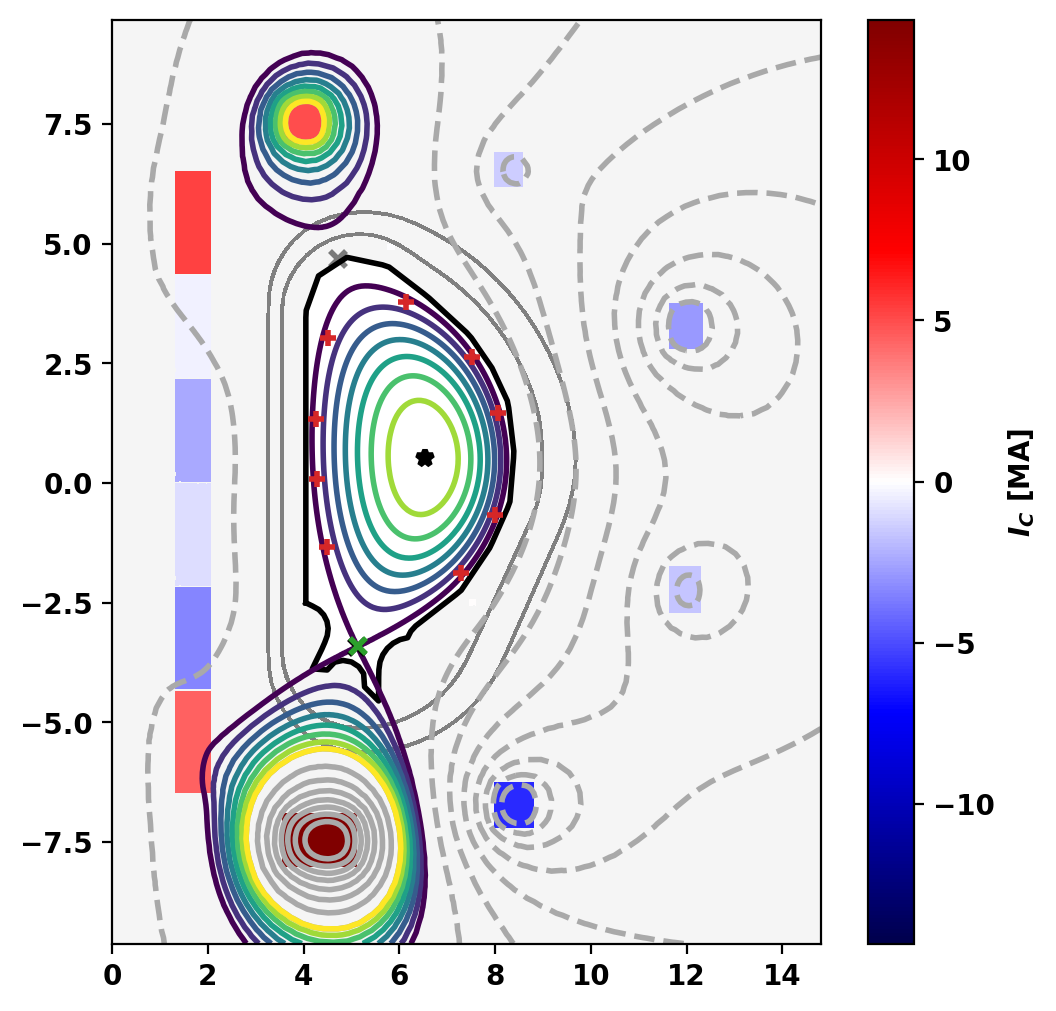

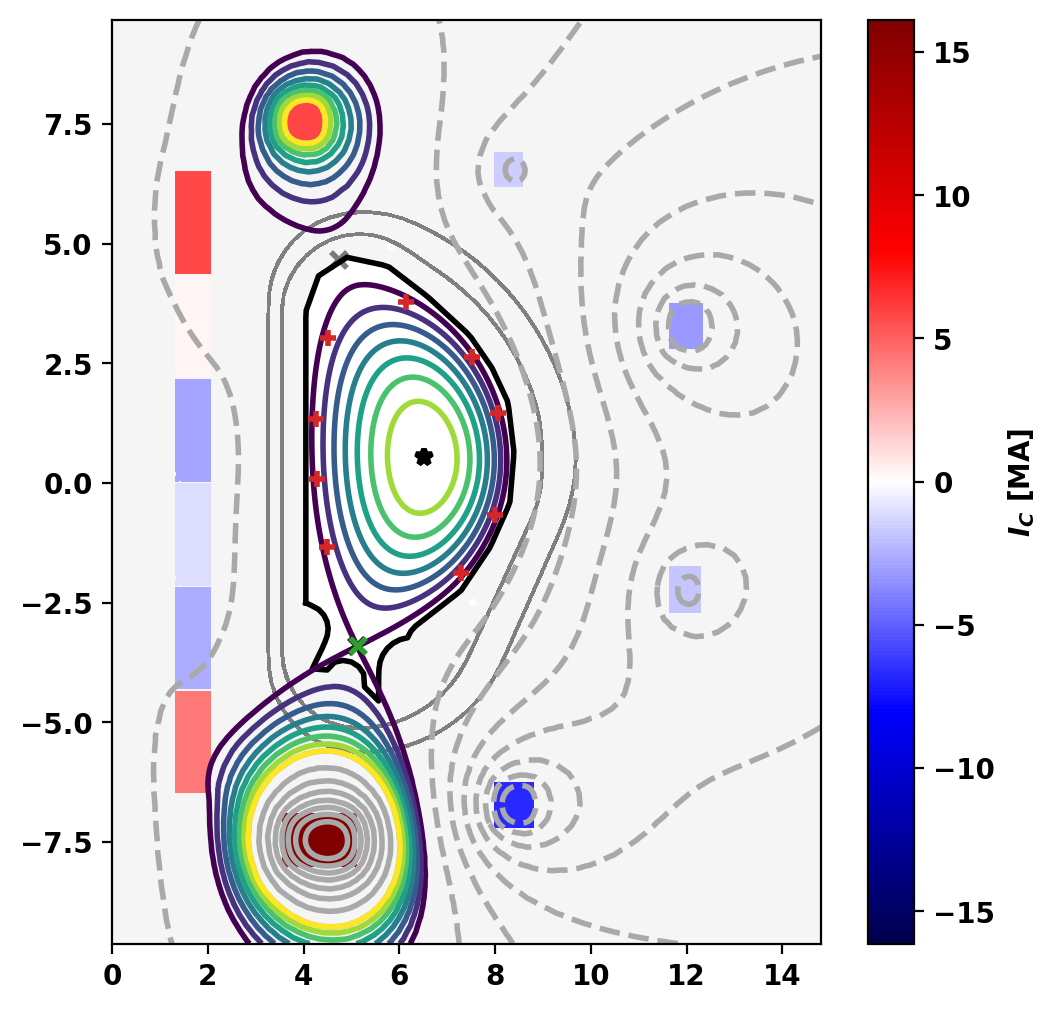

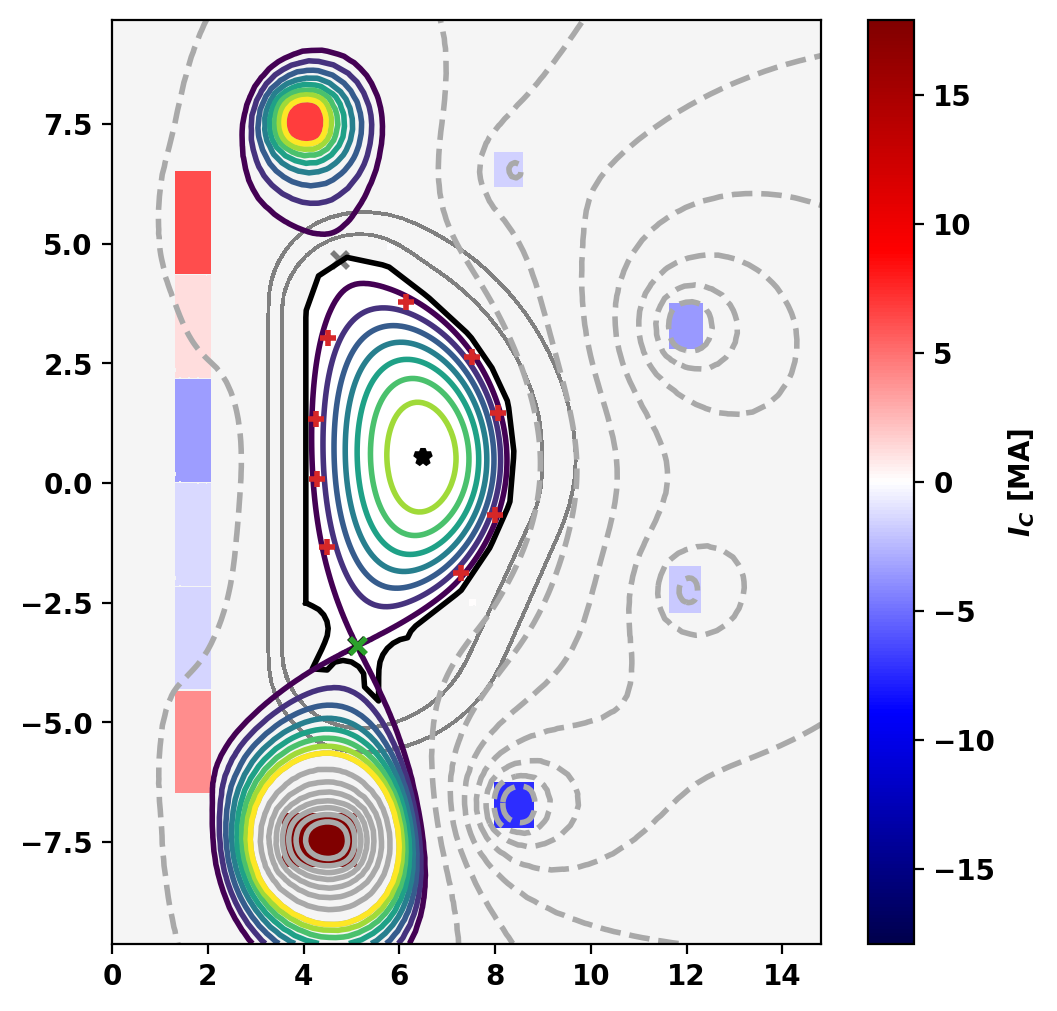

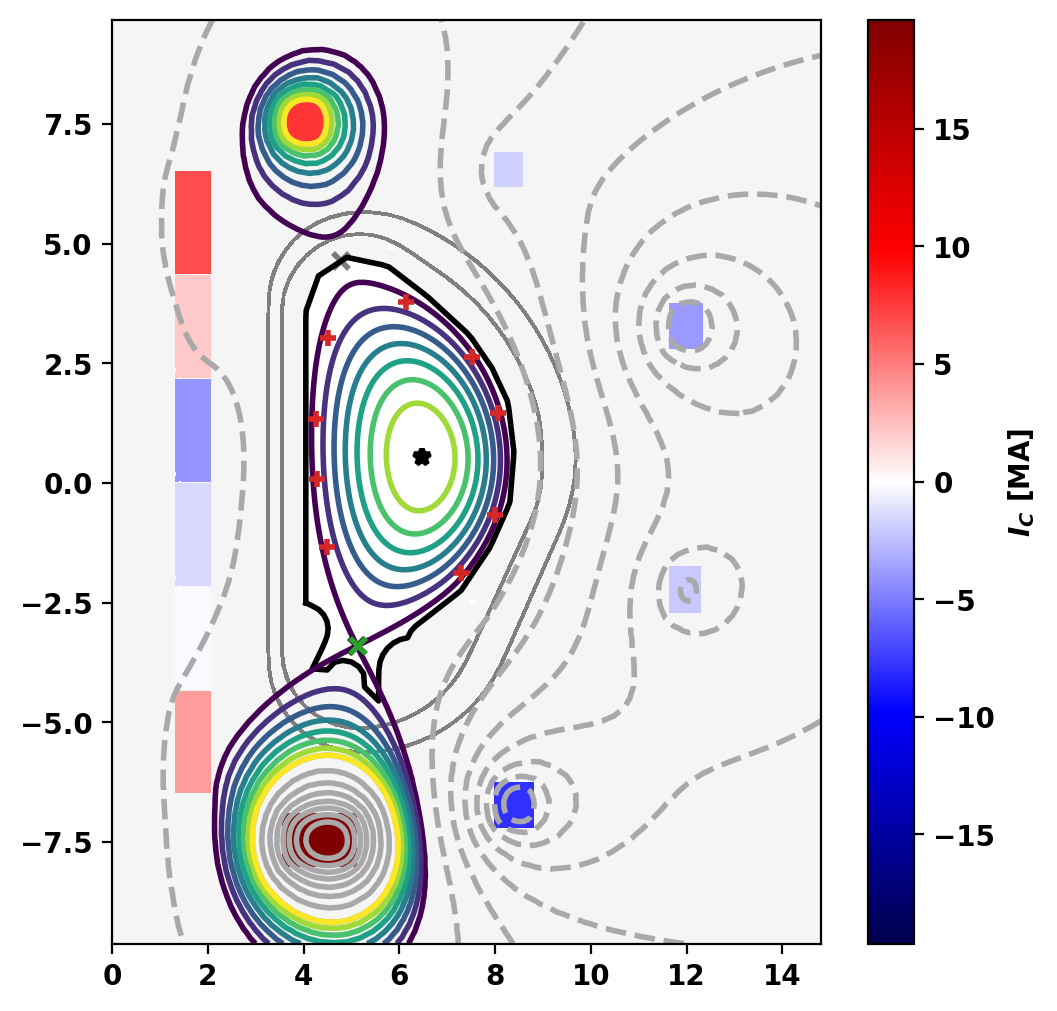

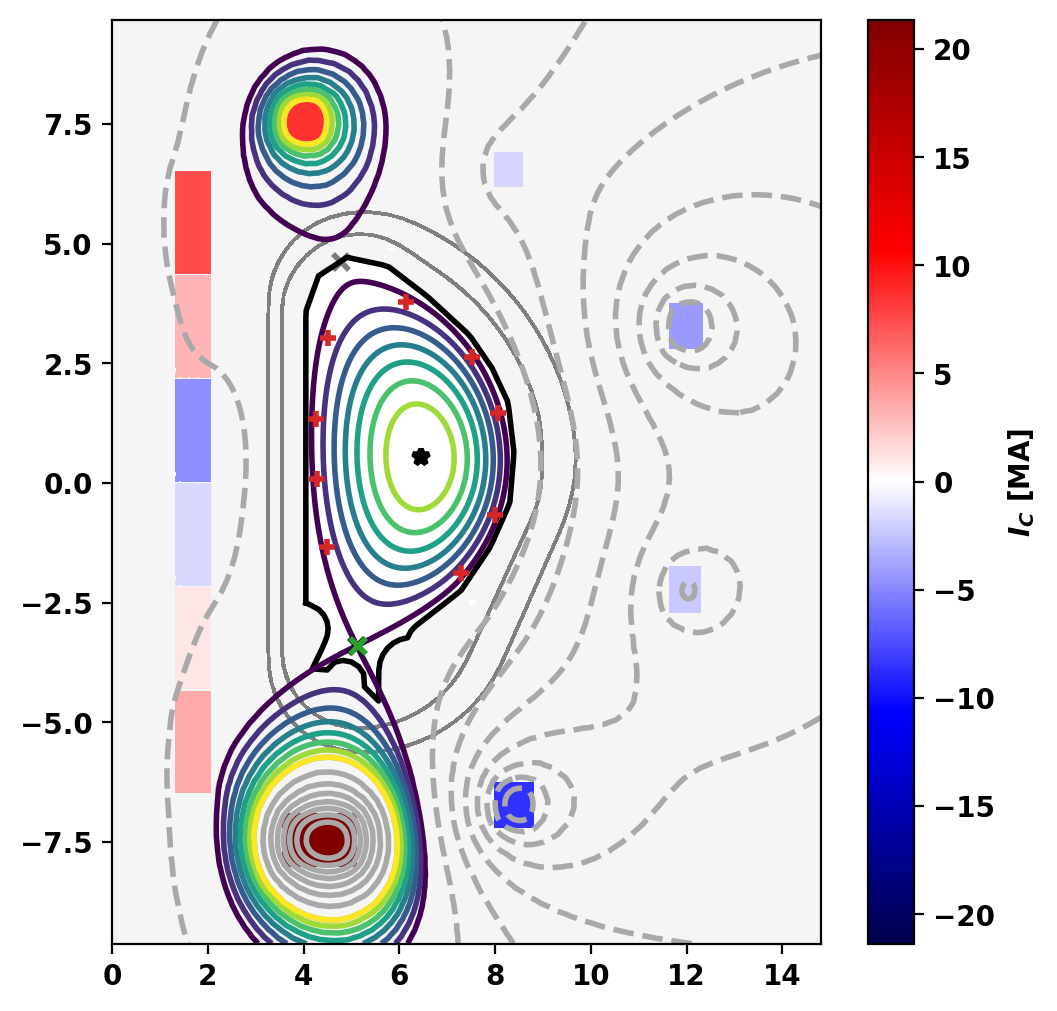

In [ ]:
i = range(0,10)
Ip_targets = np.linspace(3e6, 10.5e6, len(i))
pax_targets = np.linspace(5e3, 5e5, len(i))

for i in range(0,10):
    mygs.set_targets(Ip=Ip_targets[i], pax=pax_targets[i])
    mygs.solve()
    mygs.save_eqdsk(f'eqdsk_{i}.eqdsk', nr=200, nz=200, cocos=2, truncate_eq=False)
    # fig,ax = plt.subplots()
    # mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
    # mygs.plot_psi(fig, ax)
    # mygs.plot_constraints(fig, ax)
    mygs.print_info()


In [7]:
# # start of rampup
# Ip_target = 3e6 # A
# pax_target = 5e3
# mygs.set_targets(Ip=Ip_target, pax=pax_target)
# mygs.solve()
# fig, ax = plt.subplots()
# mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
# mygs.plot_psi(fig, ax)
# mygs.plot_constraints(fig, ax)
# mygs.print_info()
# mygs.save_eqdsk('initial.eqdsk', nr=200, nz=200, cocos=2)

In [8]:
# # flattop
# Ip_target = 10.5e6 # A
# pax_target = 5e5
# mygs.set_targets(Ip=Ip_target, pax=pax_target)
# mygs.init_psi(R0, Z, a, kappa, delta)
# mygs.solve()
# fig, ax = plt.subplots()
# mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
# mygs.plot_psi(fig, ax)
# mygs.plot_constraints(fig, ax)
# mygs.print_info()
# mygs.save_eqdsk('flattop.eqdsk', nr=200, nz=200, cocos=2)